# 01_Creacion_Dataset_maestro

En este notebook empezamos cargando `Dataset_España_base.csv` y lo unimos con `MaestroArticulos.xlsx` usando `codigoArticulo`.

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Cargar Dataset España base y Maestro Artículos
df_base = pd.read_csv('../Datasets/Dataset_España_base.csv', sep=';')
df_articulos = pd.read_excel('../Datasets/MaestroArticulos.xlsx')

# Merge usando codigoArticulo
df_maestro = pd.merge(df_base, df_articulos, left_on='codigo_articulo', right_on='CodigoArticulo', how='left')

# Visualizamos las primeras líneas
df_maestro.head()

,fecha_albaran,codigo_cliente,codigo_articulo,unidades,precio,precio_coste,importe_coste,importe_bruto,importe_neto,importe_liquido,...,PrevisionVentasAA,PrevisionVentasAP,Obsoleto,CodigoSecundario,Formula,TarifaExport,TarifaNacional,TarifaProxima,TarifaNA,FechaInstruccion
0,2021-08-13,10669,813-002,20.0,1.000,0.2732,5.4635,20.00,20.00,22.9900,...,0,0,No,NaN,3,0,0,0.0,4.40,NaT
1,2022-07-13,17128,890-122,2.0,1.000,0.1012,0.2024,2.00,2.00,2.4200,...,0,0,No,NaN,0,0,0,0.0,0.95,NaT
2,2020-09-24,50017,813-351,2.0,1.280,0.3002,0.6004,2.56,2.56,3.0976,...,0,0,No,NaN,2,0,0,0.0,4.55,NaT
3,2020-07-14,50010,813-351,4.0,1.280,0.2903,1.1613,5.12,5.12,6.1952,...,0,0,No,NaN,2,0,0,0.0,4.55,NaT
4,2024-01-15,60000,012-086,1.0,1.612,0.0366,0.0366,1.61,1.61,1.9481,...,0,0,No,NaN,0,0,0,0.0,2.90,NaT


### Eliminación de Columnas

Eliminamos algunas columnas que no utilizaremos en nuestro análisis.

In [3]:
cols_to_drop = [
    'CodigoCliente', 'CodigoArticulo', 'DescripcionArticulo', 
    'DescripcionSubfamilia', 'CodigoAreaCompetenciaLc', 
    'AreaCompetenciaLc', 'PrevisionVentasAA', 'PrevisionVentasAP'
]

# Filtrar con los que realmente existen en el DataFrame maestro por si a caso
cols_to_drop = [c for c in cols_to_drop if c in df_maestro.columns]

df_maestro = df_maestro.drop(columns=cols_to_drop)
df_maestro.head()

,fecha_albaran,codigo_cliente,codigo_articulo,unidades,precio,precio_coste,importe_coste,importe_bruto,importe_neto,importe_liquido,...,StockMaximo,FactorCrecimiento,Obsoleto,CodigoSecundario,Formula,TarifaExport,TarifaNacional,TarifaProxima,TarifaNA,FechaInstruccion
0,2021-08-13,10669,813-002,20.0,1.000,0.2732,5.4635,20.00,20.00,22.9900,...,3750,1.0,No,NaN,3,0,0,0.0,4.40,NaT
1,2022-07-13,17128,890-122,2.0,1.000,0.1012,0.2024,2.00,2.00,2.4200,...,10,1.0,No,NaN,0,0,0,0.0,0.95,NaT
2,2020-09-24,50017,813-351,2.0,1.280,0.3002,0.6004,2.56,2.56,3.0976,...,1,1.0,No,NaN,2,0,0,0.0,4.55,NaT
3,2020-07-14,50010,813-351,4.0,1.280,0.2903,1.1613,5.12,5.12,6.1952,...,1,1.0,No,NaN,2,0,0,0.0,4.55,NaT
4,2024-01-15,60000,012-086,1.0,1.612,0.0366,0.0366,1.61,1.61,1.9481,...,136062,1.0,No,NaN,0,0,0,0.0,2.90,NaT


### 1. Limpieza Inicial de Datos

Vamos a proceder a ordenar nuestro dataframe cronológicamente. Para ello, es importante asegurarnos de que la columna `fecha_albaran` está en formato fecha (datetime) y luego la ordenaremos de forma ascendente (de más antiguo a más reciente). 
Posteriormente, filtraremos el dataset para quedarnos únicamente con aquellos registros de artículos que no estén obsoletos (`Obsoleto == 'No'`).

In [4]:
# 1. Aseguramos formato datetime para la columna fecha_albaran
df_maestro['fecha_albaran'] = pd.to_datetime(df_maestro['fecha_albaran'])

# 2. Ordenamos de más antiguo a más reciente
df_maestro = df_maestro.sort_values(by='fecha_albaran', ascending=True)

# 3. Nos quedamos solo con los registros donde Obsoleto sea 'No'
df_maestro = df_maestro[df_maestro['Obsoleto'] == 'No']

print("Dimensión tras el filtrado:", df_maestro.shape)
df_maestro.head()

Dimensión tras el filtrado: (567321, 48)


,fecha_albaran,codigo_cliente,codigo_articulo,unidades,precio,precio_coste,importe_coste,importe_bruto,importe_neto,importe_liquido,...,StockMaximo,FactorCrecimiento,Obsoleto,CodigoSecundario,Formula,TarifaExport,TarifaNacional,TarifaProxima,TarifaNA,FechaInstruccion
228293,2019-01-02,11629,941-109,1.0,17.769,0.0721,0.0721,17.77,10.31,12.4751,...,2370,0.997493,No,NaN,1,-1,-1,18.967,39.95,NaT
228292,2019-01-02,11629,941-109,1.0,17.769,0.0721,0.0721,17.77,10.31,12.4751,...,2370,0.997493,No,NaN,1,-1,-1,18.967,39.95,NaT
229220,2019-01-02,11629,941-141,1.0,22.727,0.1145,0.1145,22.73,13.18,15.9478,...,890,0.997491,No,NaN,1,-1,-1,26.405,49.95,NaT
192718,2019-01-02,11732,932-014,1.0,11.529,2.3675,2.3675,11.53,6.92,8.3732,...,5300,1.018000,No,NaN,4,-1,-1,12.355,24.95,NaT
426500,2019-01-02,10497,924-793,1.0,104.959,2.1358,2.1358,104.96,57.73,69.8533,...,30,0.925000,No,NaN,2,0,-1,140.455,269.95,NaT


### 2. Análisis de Valores Nulos

Vamos a generar un reporte de todas las columnas que contienen valores nulos (missing values) y el porcentaje que representan sobre el total del dataset en este momento.

In [5]:
# Calculamos el conteo de nulos y el porcentaje respecto al total
nulos = df_maestro.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)

df_nulos = pd.DataFrame({
    'Cantidad_Nulos': nulos,
    'Porcentaje (%)': (nulos / len(df_maestro)) * 100
})

df_nulos

,Cantidad_Nulos,Porcentaje (%)
CodigoSecundario,561349,98.947333
FechaInstruccion,476187,83.936079
Municipio,1782,0.314108
Provincia,1782,0.314108


### Recomendaciones para el Tratamiento de Nulos

De acuerdo a nuestro análisis anterior, observamos que tenemos las siguientes columnas con nulos:

1. **`CodigoSecundario`** y **`FechaInstruccion`**: 
   - Estas columnas tienen una cantidad inmensamente alta de valores nulos (casi la totalidad del dataset en algunos casos o un porcentaje muy elevado).
   - **Recomendación**: La instrucción más razonable sería **eliminar estas columnas (drop)** si no aportan información crítica de negocio. Si `CodigoSecundario` sirviese para mapear algún segmento específico, podríamos simplemente rellenar los nulos con una etiqueta como `"Sin_Codigo"`. 

2. **`Municipio`** y **`Provincia`**:
   - Tienen una cantidad muy pequeña de nulos en proporción al tamaño del dataset filtrado (solo alrededor de ~1782 registros).
   - **Recomendación**: Podríamos usar la técnica de rellenado (imputación) con el valor de la categoría `"Desconocido"` o `"No Especificado"`. Alternativamente, dado que es un número tan pequeño, también se podría optar por eliminar únicamente esas filas si no representa una pérdida sustancial (aunque imputar categóricas con "Desconocido" suele ser la práctica más segura).
   


### Tratamiento de Nulos

Tal y como propusimos en las recomendaciones, vamos a proceder a limpiar el dataset según los hallazgos:
1. Eliminaremos completamente las columnas `CodigoSecundario` y `FechaInstruccion`.
2. Imputaremos un string `'Desconocido'` a aquellos registros que carecen de `Municipio` o `Provincia`.

In [6]:
# 1. Eliminación de columnas con excesivos nulos
columnas_borrar = ['CodigoSecundario', 'FechaInstruccion']
df_maestro = df_maestro.drop(columns=[c for c in columnas_borrar if c in df_maestro.columns])

# 2. Imputación de variables geográficas
df_maestro['Municipio'] = df_maestro['Municipio'].fillna('Desconocido')
df_maestro['Provincia'] = df_maestro['Provincia'].fillna('Desconocido')

# 3. Comprobación final
print("Nulos restantes en el dataset tras el tratamiento:", df_maestro.isnull().sum().sum())

Nulos restantes en el dataset tras el tratamiento: 0


### Análisis de Duplicados

Una vez tratados los nulos, el siguiente paso indispensable en las limpiezas de datos transaccionales (albaranes, tickets, facturas) es analizar si hemos cargado filas completamente idénticas (duplicados exactos del mismo registro).

In [7]:
# Calculamos el número de filas que son duplicados exactos (repetidas) 
numero_duplicados = df_maestro.duplicated().sum()

print("Buscando en una dimensión de", df_maestro.shape, "...")
print("Total de filas duplicadas encontradas:", numero_duplicados)

Buscando en una dimensión de (567321, 46) ...
Total de filas duplicadas encontradas: 15234


### Recomendaciones para el Tratamiento de Duplicados

Al analizar el conjunto de datos completo (dimensiones de filas idénticas entre sí al 100%), nos encontramos con que **existen 15.234 filas exactamente duplicadas** en toda su totalidad. 

Dado que el dataset original es de transacciones en albaranes, la aparición de filas con fechas idénticas, de los mismos artículos, para el mismo cliente, las mismas cantidades despachadas, a los mismos precios y descuentos, suele deberse a:
- **Errores de registro o inserción múltiple en origen** (frecuente en sistemas ERP si se ejecutan procesos repetidos o si se clican botones más de una vez).
- **Fallos en las cargas de los datalakes / datawarehouses**, que ocasionan un solapamiento en las mismas.

**Recomendación a seguir:**
La regla general en Machine Learning para una estructura transaccional como la nuestra es **eliminar todos los duplicados idénticos** y conservar con uno de ellos (usando la función `drop_duplicates(keep='first')`). El mantenerlos introduciría sesgo artificial incrementando excesivamente el peso de ciertos registros falsos sin ser un evento real del negocio.



### Eliminación de Duplicados

Siguiendo la recomendación, procedemos a borrar del dataframe base aquellos registros que son copias exactas en todas sus columnas, manteniendo únicamente la primera aparición.

In [8]:
# Mantenemos el primer registro de cada fila duplicada
df_maestro = df_maestro.drop_duplicates(keep='first')

# Comprobación final
print("Dimensión actual del dataset limpio:", df_maestro.shape)

Dimensión actual del dataset limpio: (552087, 46)


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuración básica visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### 1. Análisis de Outliers en Unidades

A continuación, visualizaremos la distribución de la variable `unidades` (cantidad vendida por cada línea de albarán) utilizando un diagrama de caja (boxplot). Nuestro objetivo es identificar visualmente los valores atípicos ("outliers").

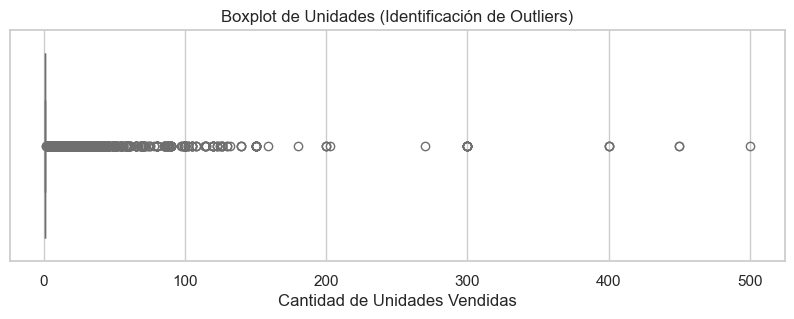

In [10]:
# Boxplot para visualizar outliers en "unidades"
plt.figure(figsize=(10, 3))
sns.boxplot(x=df_maestro['unidades'], color='skyblue')
plt.title('Boxplot de Unidades (Identificación de Outliers)')
plt.xlabel('Cantidad de Unidades Vendidas')
plt.show()

**Análisis y Conclusiones sobre los Outliers en `unidades`:**

- **¿A qué se deben estos outliers?** Como observamos en el boxplot, la gran inmensa mayoría de los albaranes consisten en la venta de 1 o 2 unidades (típicamente venta retail/B2C a usuario final). Sin embargo, vemos puntos que sobrepasan las 100, 200 e incluso llegan a 500 unidades. Estos valores seguramente correspondan a **ventas B2B o grandes distribuidores** (compras al por mayor) o a componentes extremadamente pequeños/consumibles que se venden en lotes.
- **¿Qué decisión tomar pensando en Machine Learning?** Dado que nuestro objetivo a futuro es un modelo Predictivo de Demanda (como Gradient Boosting), **NO debemos eliminar estos outliers**. Son eventos de negocio reales que representan pedidos masivos de distribuidores. Eliminarlos provocaría que el modelo subestime drásticamente los picos de demanda.
- **Recomendación:** Mantenerlos en el dataset. Como usaremos modelos basados en árboles (Gradient Boosting), estos algoritmos son **robustos ante outliers**, ya que se centran en los umbrales de partición (splits) y no se ven distorsionados severamente por la magnitud extrema del valor como ocurriría en una regresión lineal tradicional. Si en el futuro fuera estrictamente necesario estabilizar la varianza, se podría optar por escalar la variable o aplicar *clipping* (Winsorization) en un percentil muy alto (p.ej. percentil 99.5), pero de base se deben conservar.

### 2. Análisis Estadístico de la variable "Unidades"

Ahora exploraremos la distribución matemática de `unidades` y sus estadísticos descriptivos básicos.

count    552087.000000
mean          1.520137
std           3.420073
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         500.000000
Name: unidades, dtype: float64

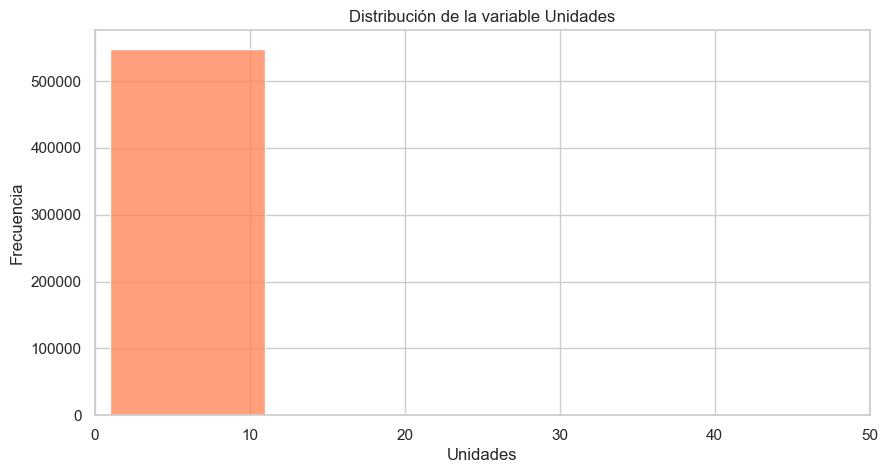

In [11]:
# Estadísticos descriptivos
display(df_maestro['unidades'].describe())

# Histograma para ver la distribución
plt.figure(figsize=(10, 5))
sns.histplot(df_maestro['unidades'], bins=50, kde=False, color='coral')
plt.title('Distribución de la variable Unidades')
plt.xlabel('Unidades')
plt.ylabel('Frecuencia')
# Limitamos el eje X a un valor razonable para poder ver la masa principal
plt.xlim(0, 50) 
plt.show()

**Conclusión estadística:** La variable `unidades` presenta una métrica descriptiva abrumadoramente sesgada hacia la derecha (Right-Skewed). El primer cuartil (25%), la mediana (50%) y el tercer cuartil (75%) son exactamente 1, lo que indica que en más de un 75% de las transacciones solo se vende una única unidad. La media se eleva a ~1.5 debido a la cola pesada provocada por los pedidos atípicos mayores (outliers). Sigue una distribución muy asimétrica parecida a una distribución de Poisson, típica en recuentos de ítems vendidos.

### 3. Matriz de Correlación Numérica

Procedemos a evaluar la relación lineal (correlación de Pearson) entre las variables numéricas para detectar fuertes dependencias, variables redundantes, y ver qué factores se correlacionan en mayor medida con las unidades compradas o generadas en el margen.

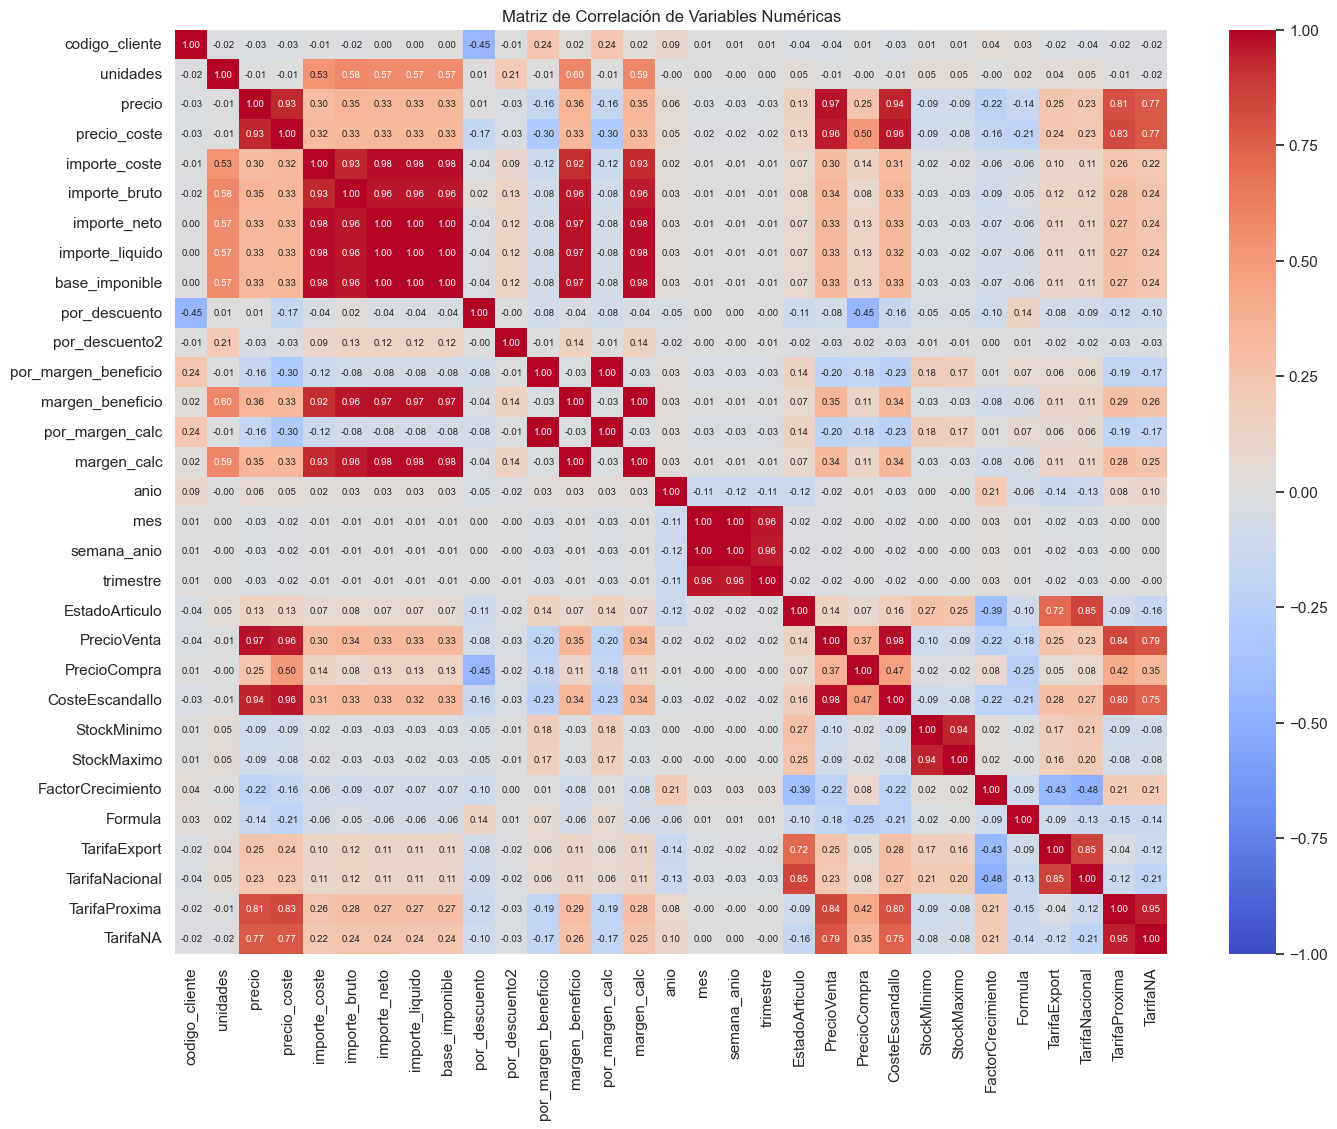

Correlaciones más altas respecto a 'unidades':


unidades            1.000000
margen_beneficio    0.595650
margen_calc         0.589856
importe_bruto       0.581250
base_imponible      0.568543
importe_neto        0.568514
importe_liquido     0.568251
importe_coste       0.530821
por_descuento2      0.208386
Name: unidades, dtype: float64

In [12]:
# Seleccionamos mediante select_dtypes únicamente las variables numéricas
numericas = df_maestro.select_dtypes(include=[np.number])

# Calculamos matriz de correlación completa
corr_matrix = numericas.corr()

# Dibujamos un Heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, annot_kws={'size': 7}, fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

# Veamos las variables que mejor correlacionan con 'unidades'
print("Correlaciones más altas respecto a 'unidades':")
corr_target = corr_matrix['unidades'].abs().sort_values(ascending=False)
display(corr_target[corr_target > 0.1])

### 4. Pair Plot de las Variables Más Correlacionadas

Utilizamos un `pairplot` para observar de forma dispersa las interacciones múltiples entre un subconjunto de variables. Tomaremos `unidades` y otras variables altamente correlacionadas según la matriz previa (por ejemplo: `importe_bruto`, `base_imponible` y `margen_beneficio`).
*Nota: Se usará una muestra subconjunto aleatoria (sample de 10,000 registros) para que tarde menos y sea interpretable visualmente.*

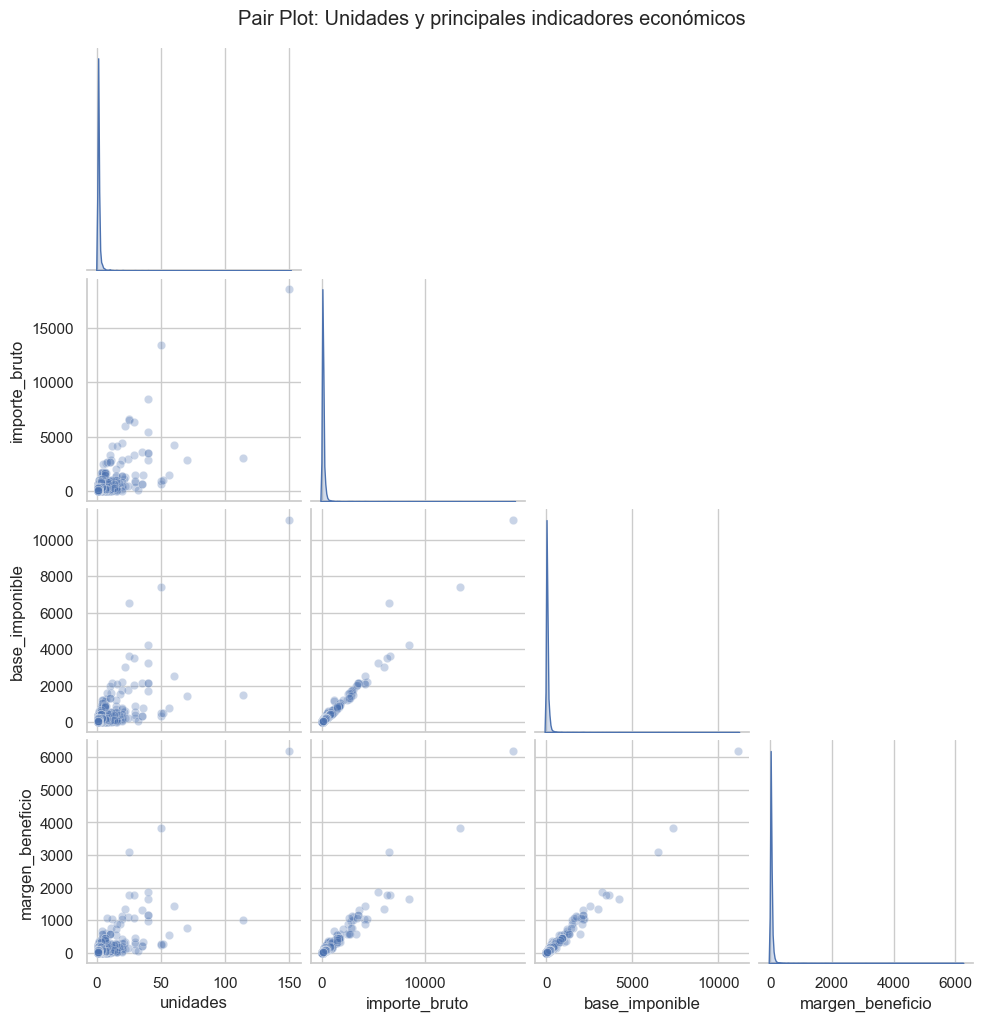

In [13]:
# Seleccionamos las variables clave extraídas del análisis previo
vars_pairplot = ['unidades', 'importe_bruto', 'base_imponible', 'margen_beneficio']

# Tomamos una muestra aleatoria para pintar el pairplot más rápido
df_sample = df_maestro[vars_pairplot].dropna().sample(n=10000, random_state=42)

sns.pairplot(df_sample, corner=True, diag_kind='kde', plot_kws={'alpha': 0.3})
plt.suptitle('Pair Plot: Unidades y principales indicadores económicos', y=1.02)
plt.show()

### Recomendaciones para Próximos Pasos

Basado en el análisis estadístico previo, mis sugerencias para las siguientes etapas del proyecto son:

1. **Agrupación a nivel Temporal (Feature Engineering de Demanda)**: 
   Actualmente tenemos el Dataset en granularidad *"Línea de Albarán"*. Dado que la predicción típica se hace agrupando el número de artículos de forma diaria, semanal o mensual (en función de un Time Series o un Regresor Machine Learning general), el próximo paso capital será **realizar agrupaciones de demanda (groupby)** a nivel "Anio, Mes, Semana" por cada "Articulo" sumando las unidades vendidas totales. 

2. **Ingeniería de Características (Features)**:
   Si vamos a predecir demanda con Gradient Boosting usando este dataset central como *"Feature Store"*, deberíamos extraer variables estacionales (`mes`, `dia de la semana`, `cuatrimestre`), e introducir **lags temporales** (ventas pasadas $t-1$, $t-2$... semanales) así como **medias móviles** de la variable target (`unidades`).

3. **Dimensionalidad y variables Redundantes**:
   En el análisis de correlación hemos visto variables como `base_imponible`, `importe_bruto`, e `importe_neto` completamente correlacionadas consigo mismas (multicolinealidad muy alta). Antes de entrenar el modelo (o en la fase de ML), debemos seleccionar solo UNA de esas variables o quitarlas, ya que aportarán ruido al modelo ensamble de árboles.

### Eliminación de Variables con Multicolinealidad

La matriz de correlación (ahora con los factores exactos impresos arriba) nos muestra una correlación de casi **1.00 (100%)** entre variables económicas como:
- `importe_bruto`
- `importe_neto`
- `importe_liquido`
- `base_imponible`

Además, tenemos métricas redundantes provenientes del cruce (por ejemplo `margen_beneficio`, `margen_calc`, y `por_margen_calc`). 

**¿Por qué eliminar la multicolinealidad?**
Para modelos de Machine Learning (incluso aquellos basados en árboles que son parcialmente inmunes), tener variables de entrada o features que significan virtualmente lo mismo introduce una alta correlación cruzada ("multicolinealidad"). Esto no añade nueva información al modelo de predicción, ralentiza enormemente el tiempo de entrenamiento y añade confusión sobre qué variable es realmente importante (feature importance).

**Decisión**: 
Nos quedaremos únicamente con una variable principal de facturación neta (`importe_neto`) y con variables unitarias en vez de importes totales (las matemáticas del sistema ya nos las calculan con `precio` y `unidades`). Vamos a proceder a borrar el resto.

In [14]:
# Variables altamente redundantes a eliminar
cols_multicolinealidad = [
    'importe_bruto', 
    'importe_liquido', 
    'base_imponible',
    'margen_calc',
    'por_margen_calc',
    'por_descuento2' # Suele ser 0 o redundante con el descuento 1
]

# Las eliminamos del dataset
df_maestro = df_maestro.drop(columns=[c for c in cols_multicolinealidad if c in df_maestro.columns])

print("Variables redundantes eliminadas. Dimensión actual:", df_maestro.shape)

Variables redundantes eliminadas. Dimensión actual: (552087, 40)


### Guardado del Dataset Limpio

Finalmente, exportamos el estado actual del dataframe limpio a un nuevo fichero CSV que nos servirá como punto de partida inequívoco para las próximas fases de modelado y cruces adicionales (calendario ciclista, factores externos).

In [15]:
# Guardamos a formato CSV (respetando separador ';')
path_export = '../Datasets/df_españa_limpio.csv'
df_maestro.to_csv(path_export, index=False, sep=';')

print("Fichero guardado finalizado exitosamente en:", path_export)

Fichero guardado finalizado exitosamente en: ../Datasets/df_españa_limpio.csv
